# Texas Salary Prediction

### AIM : This project analyzes salary data across Texas state government agencies to understand payroll structure, equity, and trends, and to build a predictive model for estimating employee salaries

In [1]:
import pandas as pd ## Importing Libraries
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r"C:\Users\rohit\Desktop\Datamites Data\Texas salary data\salary.csv")  #reading dataset
df.head(2)

C:\Users\rohit\AppData\Local\Temp\ipykernel_13684\4226340376.py:1: DtypeWarning: Columns (16,18,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(r"C:\Users\rohit\Desktop\Datamites Data\Texas salary data\salary.csv")  #reading dataset


,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,...,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,75.96150,29.0,9545.82,114549.84,127717,True,NaN,NaN,131407.08,NaN
1,212,OFFICE OF COURT ADMINISTRATION ...,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,...,81.04454,4.0,1404.77,16857.24,127717,True,NaN,NaN,NaN,True


In [3]:
df.shape

(149481, 21)

In [4]:
df.info() #checking data type, null values and columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149481 entries, 0 to 149480
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   AGENCY                   149481 non-null  int64  
 1   AGENCY NAME              149481 non-null  object 
 2   LAST NAME                149481 non-null  object 
 3   FIRST NAME               149481 non-null  object 
 4   MI                       149481 non-null  object 
 5   CLASS CODE               149481 non-null  object 
 6   CLASS TITLE              149481 non-null  object 
 7   ETHNICITY                149481 non-null  object 
 8   GENDER                   149481 non-null  object 
 9   STATUS                   149481 non-null  object 
 10  EMPLOY DATE              149481 non-null  object 
 11  HRLY RATE                149481 non-null  float64
 12  HRS PER WK               149481 non-null  float64
 13  MONTHLY                  149481 non-null  float64
 14  ANNU

In [5]:
df['EMPLOY DATE']=pd.to_datetime(df['EMPLOY DATE']) ##changing datatype of column

C:\Users\rohit\AppData\Local\Temp\ipykernel_13684\530485985.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['EMPLOY DATE']=pd.to_datetime(df['EMPLOY DATE']) ##changing datatype of column


In [6]:
df.drop(['duplicated','multiple_full_time_jobs','combined_multiple_jobs','summed_annual_salary','hide_from_search'],axis=1,inplace=True) #deleting columns having a very less amount of data and it affects the output


In [7]:
df['year of service']=2026-df['EMPLOY DATE'].dt.year  # creating a new column for year of experience a person have

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149481 entries, 0 to 149480
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   AGENCY           149481 non-null  int64         
 1   AGENCY NAME      149481 non-null  object        
 2   LAST NAME        149481 non-null  object        
 3   FIRST NAME       149481 non-null  object        
 4   MI               149481 non-null  object        
 5   CLASS CODE       149481 non-null  object        
 6   CLASS TITLE      149481 non-null  object        
 7   ETHNICITY        149481 non-null  object        
 8   GENDER           149481 non-null  object        
 9   STATUS           149481 non-null  object        
 10  EMPLOY DATE      149481 non-null  datetime64[ns]
 11  HRLY RATE        149481 non-null  float64       
 12  HRS PER WK       149481 non-null  float64       
 13  MONTHLY          149481 non-null  float64       
 14  ANNUAL           149

In [9]:
df.shape

(149481, 17)

In [10]:
df[df.duplicated()]  #checking for duplicate values

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,year of service


In [11]:
df.shape

(149481, 17)

In [12]:
df['year of service'].value_counts()  # checking incorrect data and removing

year of service
 7     22017
 9     20447
 8     15940
 6     14557
 10    11387
 11     7107
 12     6328
 13     6006
 14     4831
 18     3907
 22     3548
 17     3513
 15     3455
 19     3356
 16     2963
 20     2878
 21     2665
 24     1682
 26     1629
 25     1598
 23     1468
 27     1341
 28     1210
 29      960
 30      918
 31      774
 32      725
 33      523
 34      511
 36      216
 35      203
 37      199
 39      138
 38      129
 41       84
 40       77
 42       53
 43       41
 45       29
 44       21
 47       12
 46       10
 49        7
 50        5
 48        5
-43        2
-47        2
-45        1
-49        1
-46        1
-42        1
Name: count, dtype: int64

In [13]:
len(df[df['year of service']<0]) #Checking negative year of experience

8

In [14]:
df1=df[df['year of service']>0] #removing negative year of experience

In [15]:
df1.shape

(149473, 17)

In [16]:
df1.sort_values(by='ANNUAL',ascending=False).head(2)

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,year of service
83851,542,CANCER PREVENTION AND RESEARCH INSTITUTE OF TE...,WILLSON,JAMES,,C542,CHIEF SCIENTIFIC OFFICER ...,WHITE,MALE,ERF - EXEMPT REGULAR FULL-TIME,2016-03-01,0.0,40.0,46125.00,553500.00,372291,10
144232,327,EMPLOYEES RETIREMENT SYSTEM ...,TULL,CHARLES,T,D136,DIRECTOR OF INVESTMENTS ...,WHITE,MALE,URF - UNCLASSIFIED REGULAR FULL-TIME,2009-02-01,0.0,40.0,37500.00,450000.00,24680,17
14793,323,TEACHER RETIREMENT SYSTEM ...,AUBY,JASE,R,C204,CHIEF INVESTMENT OFFICER ...,WHITE,MALE,ERF - EXEMPT REGULAR FULL-TIME,2009-11-09,0.0,40.0,37500.00,450000.00,121522,17
15154,323,TEACHER RETIREMENT SYSTEM ...,LANG,ERIC,L,U105,SENIOR MANAGING DIRECTOR ...,WHITE,MALE,URF - UNCLASSIFIED REGULAR FULL-TIME,2006-02-01,0.0,40.0,32666.66,391999.92,124553,20
136727,701,TEXAS EDUCATION AGENCY ...,TIMMINS III,BARNEY,H,701I,PSF CHIEF INVESTMENT OFFICER ...,WHITE,MALE,ERF - EXEMPT REGULAR FULL-TIME,2000-10-16,0.0,40.0,32031.25,384375.00,7792,26
15041,323,TEACHER RETIREMENT SYSTEM ...,GUTHRIE,BRIAN,K,E176,EXECUTIVE DIRECTOR ...,WHITE,MALE,ERF - EXEMPT REGULAR FULL-TIME,2008-10-01,0.0,40.0,29595.12,355141.44,147935,18
15539,323,TEACHER RETIREMENT SYSTEM ...,WEST,DALE,E,U105,SENIOR MANAGING DIRECTOR ...,AM INDIAN,MALE,URF - UNCLASSIFIED REGULAR FULL-TIME,2008-02-19,0.0,40.0,28666.67,344000.04,14408,18
84769,601,TEXAS DEPARTMENT OF TRANSPORTATION ...,BASS,JAMES,M,E021,EXECUTIVE DIRECTOR ...,WHITE,MALE,ERF - EXEMPT REGULAR FULL-TIME,1989-05-22,0.0,40.0,28666.66,343999.92,90927,37
144262,327,EMPLOYEES RETIREMENT SYSTEM ...,WILSON,PORTER,M,E154,EXECUTIVE DIRECTOR FOR ERS ...,WHITE,MALE,ERF - EXEMPT REGULAR FULL-TIME,2015-01-12,0.0,40.0,26343.08,316116.96,126804,11
15349,323,TEACHER RETIREMENT SYSTEM ...,RANDALL,NEIL,A,U106,MANAGING DIRECTOR ...,WHITE,MALE,URF - UNCLASSIFIED REGULAR FULL-TIME,2007-11-01,0.0,40.0,26250.00,315000.00,113006,19


In [17]:
df1.describe()  #checking various parameter of numerical columns

,AGENCY,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,year of service
count,149473.000000,149473,149473.000000,149473.000000,149473.000000,149473.000000,1.494730e+05,149473.000000
mean,545.743151,2014-01-12 21:47:51.729342208,0.345998,39.714976,4226.151079,50713.812947,5.652180e+05,12.458310
min,101.000000,1976-03-15 00:00:00,0.000000,1.000000,50.000000,600.000000,1.000000e+00,6.000000
25%,529.000000,2010-12-20 00:00:00,0.000000,40.000000,3019.840000,36238.080000,1.133410e+05,8.000000
50%,530.000000,2016-10-10 00:00:00,0.000000,40.000000,3720.170000,44642.040000,3.463850e+05,10.000000
75%,696.000000,2018-12-03 00:00:00,0.000000,40.000000,4865.720000,58388.640000,1.100503e+06,16.000000
max,930.000000,2020-06-30 00:00:00,117.788480,70.000000,46125.000000,553500.000000,1.271604e+06,50.000000
std,139.048486,NaN,4.207053,2.323751,2093.042604,25116.511252,4.786217e+05,6.791371


In [18]:
df1.describe(include=object)  #checking various parameter of non numerical columns

,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS
count,149473,149473,149473,149473,149473,149473,149473,149473,149473
unique,113,38672,23558,27,1481,1422,6,2,11
top,HEALTH AND HUMAN SERVICES COMMISSION ...,SMITH,MICHAEL,,4504,CORREC OFFICER IV ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME
freq,36667,1243,1843,38407,9267,9267,67135,85325,142497


In [19]:
df2=df1.drop(['AGENCY NAME','LAST NAME','FIRST NAME','MI','CLASS CODE','CLASS TITLE','ETHNICITY','GENDER','STATUS','EMPLOY DATE'],axis=1) #removing non-numerical columns
df2.columns

Index(['AGENCY', 'HRLY RATE', 'HRS PER WK', 'MONTHLY', 'ANNUAL',
       'STATE NUMBER', 'year of service'],
      dtype='object')

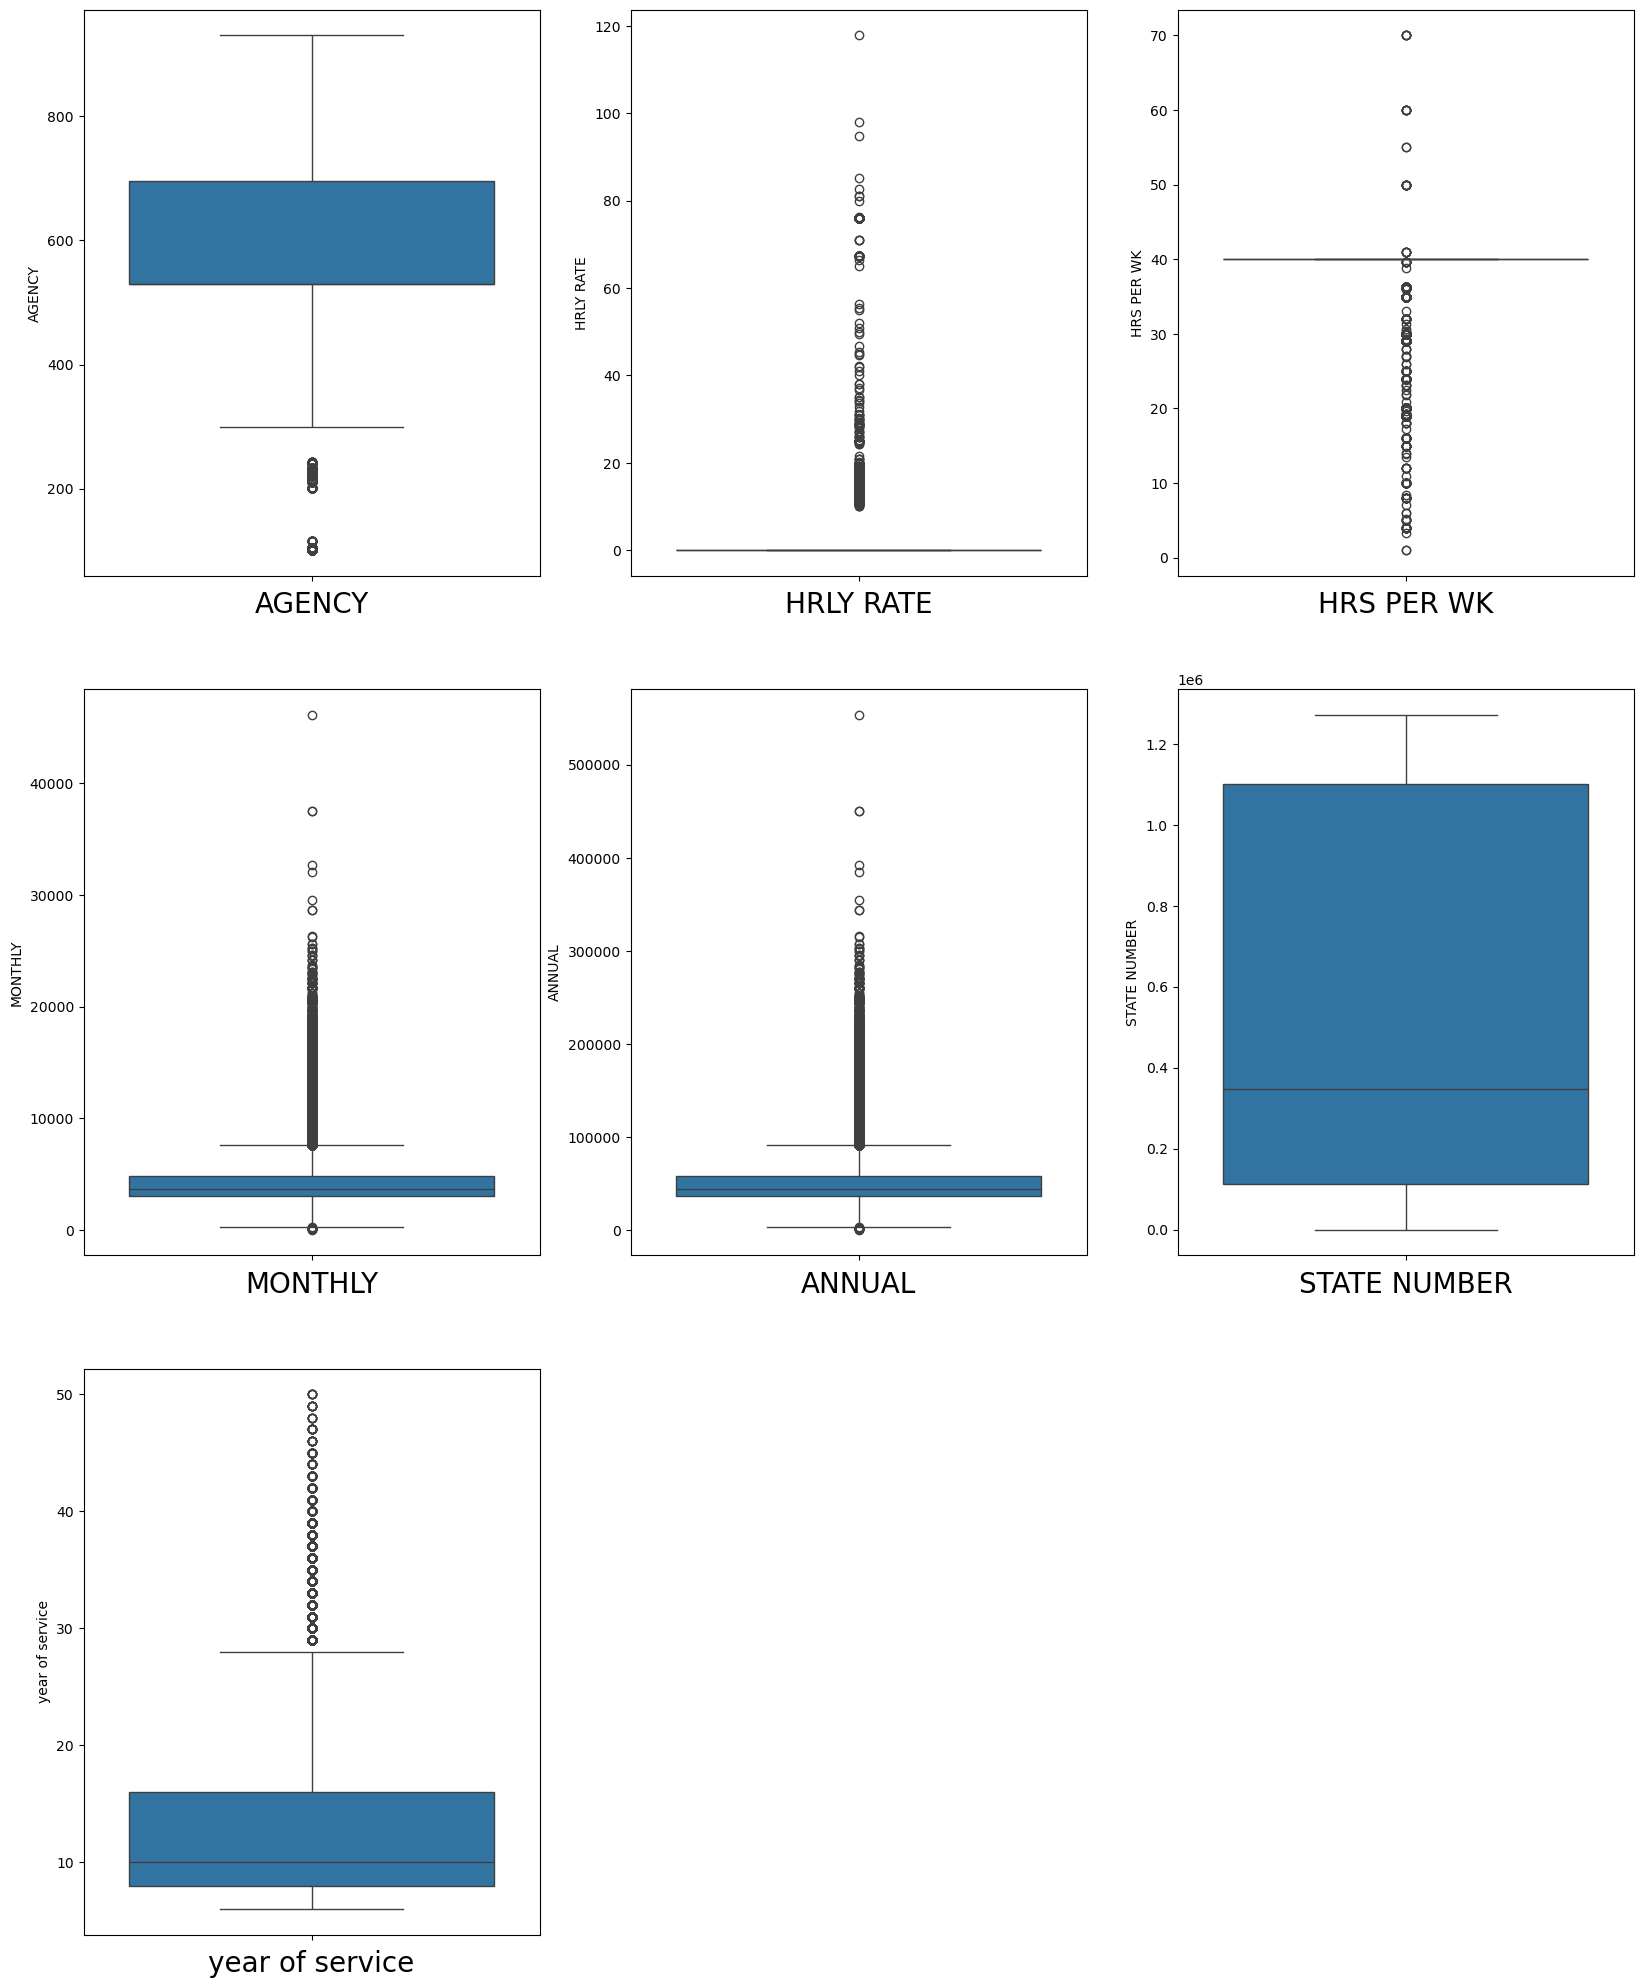

In [20]:
plt.figure(figsize=(20,25), facecolor='white') ## Visualizing each columns using boxplot to detect the outlier and remove it.
plotnumber = 1

for column in df2:
    if plotnumber<=7:     # as there are 9 columns in the data
        ax = plt.subplot(3,3,plotnumber)
        sns.boxplot(df2[column])
        plt.xlabel(column,fontsize=20)
        #plt.ylabel('Salary',fontsize=20)
    plotnumber+=1
plt.show()

In [21]:
df1.shape

(149473, 17)

In [22]:
df1=df1[df1['HRLY RATE']<90]  #removing extreme values of outlier 

<Axes: >

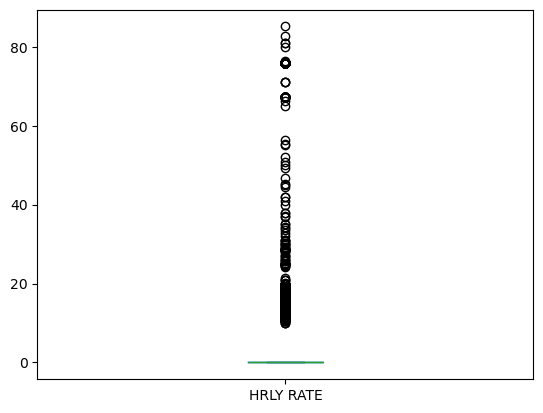

In [23]:
df1['HRLY RATE'].plot(kind='box')

In [24]:
df1=df1[df1['HRS PER WK']<45] #removing extreme values of outlier 

<Axes: >

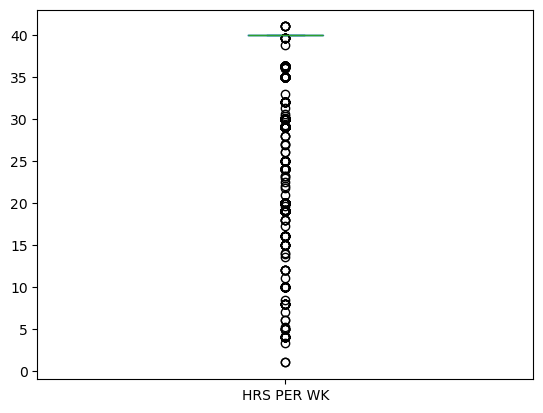

In [25]:
df1['HRS PER WK'].plot(kind='box')

In [26]:
df1=df1[df1['MONTHLY']<28000] #removing extreme values of outlier 

<Axes: >

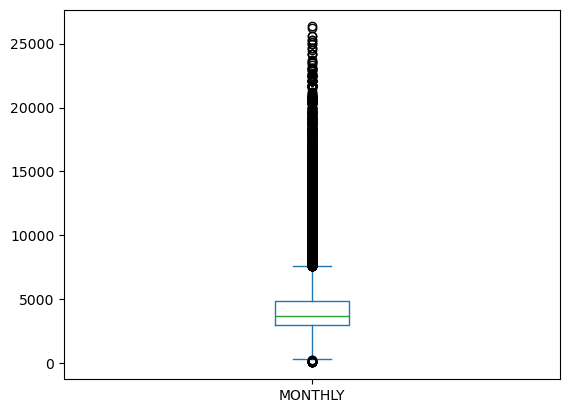

In [27]:
df1['MONTHLY'].plot(kind='box')

In [28]:
df1=df1[df1['ANNUAL']<320000]  #removing extreme values of outlier 

<Axes: >

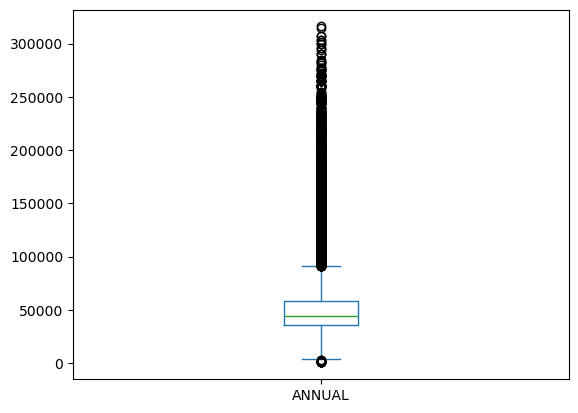

In [29]:
df1['ANNUAL'].plot(kind='box')

In [30]:
df1.shape

(149442, 17)

## data cleaning completed

In [31]:
df1.columns

Index(['AGENCY', 'AGENCY NAME', 'LAST NAME', 'FIRST NAME', 'MI', 'CLASS CODE',
       'CLASS TITLE', 'ETHNICITY', 'GENDER', 'STATUS', 'EMPLOY DATE',
       'HRLY RATE', 'HRS PER WK', 'MONTHLY', 'ANNUAL', 'STATE NUMBER',
       'year of service'],
      dtype='object')

In [32]:
for col in df1.describe().columns: # analysing unique values in each numerical column.
    print(col)
    print(df1[col].unique())
    print('-'*50)

AGENCY
[241 212 696 302 601 510 520 537 530 529 551 771 772 101 104 102 303 809
 103 105 201 211 213 215 221 222 223 224 225 226 227 228 229 230 231 232
 233 234 242 243 300 301 304 306 307 313 320 323 326 329 332 338 352 360
 401 403 405 407 448 452 454 455 457 458 459 460 464 469 473 479 481 503
 508 513 515 533 542 554 608 644 701 781 802 813 907 930 116 305 308 312
 327 347 356 359 362 364 409 411 450 451 456 466 475 476 477 504 507 514
 578 580 582 592 808]
--------------------------------------------------
EMPLOY DATE
<DatetimeArray>
['1988-02-18 00:00:00', '2015-02-01 00:00:00', '2020-02-01 00:00:00',
 '2018-09-01 00:00:00', '2020-06-29 00:00:00', '2020-04-01 00:00:00',
 '2020-06-22 00:00:00', '2020-03-01 00:00:00', '2020-03-04 00:00:00',
 '2019-09-01 00:00:00',
 ...
 '2016-11-29 00:00:00', '1995-07-06 00:00:00', '2003-10-03 00:00:00',
 '1996-11-26 00:00:00', '1991-10-14 00:00:00', '2013-01-23 00:00:00',
 '2011-09-16 00:00:00', '2018-10-30 00:00:00', '2005-06-09 00:00:00',
 '198

In [33]:
for col in df1.describe(include=object).columns: # analysing unique values in each non numerical column.
    print(col)
    print(df1[col].unique())
    print('-'*50)

AGENCY NAME
['COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECTION '
 'OFFICE OF COURT ADMINISTRATION                    '
 'TEXAS DEPARTMENT OF CRIMINAL JUSTICE              '
 'OFFICE OF THE ATTORNEY GENERAL                    '
 'TEXAS DEPARTMENT OF TRANSPORTATION                '
 'TEXAS BEHAVIORAL HEALTH EXECUTIVE COUNCIL         '
 'BOARD OF EXAMINERS OF PSYCHOLOGISTS               '
 'DEPARTMENT OF STATE HEALTH SERVICES               '
 'DEPARTMENT OF FAMILY AND PROTECTIVE SERVICES      '
 'HEALTH AND HUMAN SERVICES COMMISSION              '
 'DEPARTMENT OF AGRICULTURE                         '
 'SCHOOL FOR THE BLIND AND VISUALLY IMPAIRED        '
 'SCHOOL FOR THE DEAF                               '
 'SENATE                                            '
 'LEGISLATIVE BUDGET BOARD                          '
 'HOUSE OF REPRESENTATIVES                          '
 'TEXAS FACILITIES COMMISSION                       '
 'STATE PRESERVATION BOARD                          '
 'TEXAS LEGISLAT

In [34]:
df1.groupby('CLASS TITLE',as_index=False)['ANNUAL'].mean().sort_values(by='ANNUAL',ascending=False) # analysing annual income classwise

,CLASS TITLE,ANNUAL
493,EXECUTIVE DIRECTOR FOR ERS ...,316116.96
825,MANAGING DIRECTOR ...,310999.98
200,CHIEF COMPLIANCE OFFICER ...,295800.00
1208,SENIOR MANAGING DIRECTOR ...,294500.01
484,EX DIRECTOR TDCJ ...,275500.92
...,...,...
1149,RESIDENT SPECIALIST I ...,15229.96
240,"COMMISS, CANADIAN RIVER COMPAC ...",11036.16
244,"COMMISS, SABINE RIVER COMPACT ...",8699.16
838,MED TECHNOLOGIST TRAINEE ...,7200.00


In [35]:
manager_dir = df[df['CLASS TITLE'].str.contains("MANAG|DIRECTOR|CHIEF", case=False, na=False)] # data distributed as manager role and non manager role
employee = df[~df['CLASS TITLE'].str.contains("MANAG|DIRECTOR|CHIEF", case=False, na=False)]


In [36]:
md=manager_dir.groupby('CLASS TITLE')[['ANNUAL']].mean().sort_values(by='ANNUAL',ascending=False).head(20)
emp=employee.groupby('CLASS TITLE')[['ANNUAL']].mean().sort_values(by='ANNUAL',ascending=False).head(20)


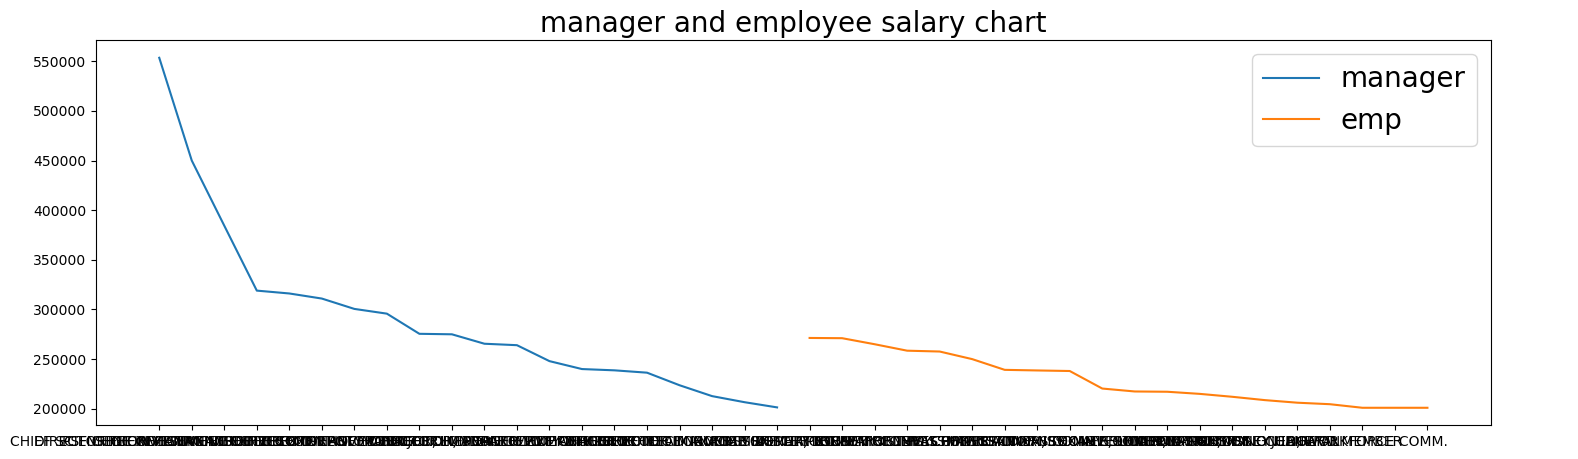

In [37]:
plt.figure(figsize=(18,5))  #visualizing manager and employee salary difference using chart as positionwise and it clearly shows that there is a huge difference in there salary
plt.title('manager and employee salary chart',fontsize=20)
plt.plot(md.index,md['ANNUAL'],label='manager')
plt.plot(emp.index,emp['ANNUAL'],label='emp')
plt.legend(fontsize=20)
plt.show()

<Axes: xlabel='CLASS TITLE', ylabel='ANNUAL'>

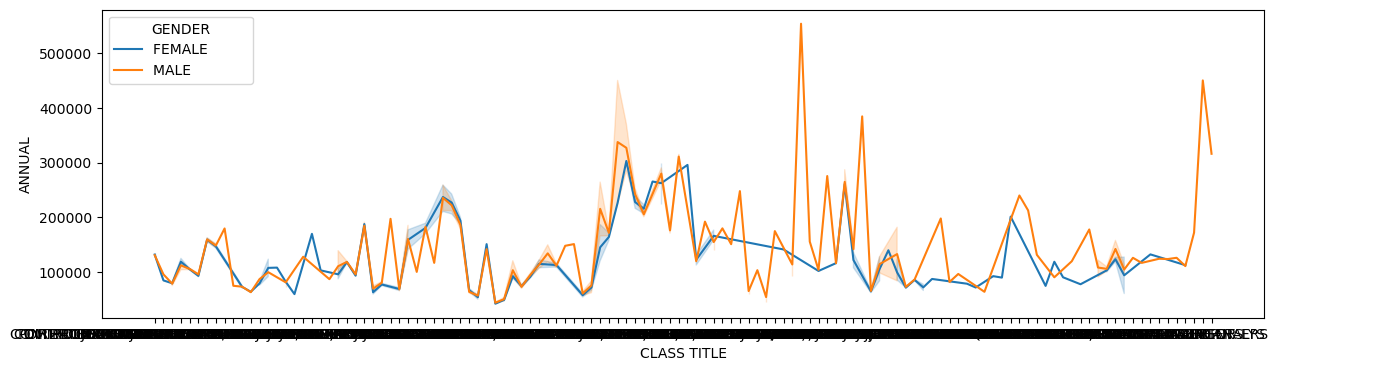

In [38]:
plt.figure(figsize=(15,4)) #visualizing manager level salary difference using chart Genderwise and there is sufficient difference in the salary for same position 
sns.lineplot(x='CLASS TITLE',y='ANNUAL',data=manager_dir,hue='GENDER')

<Axes: xlabel='CLASS TITLE', ylabel='ANNUAL'>

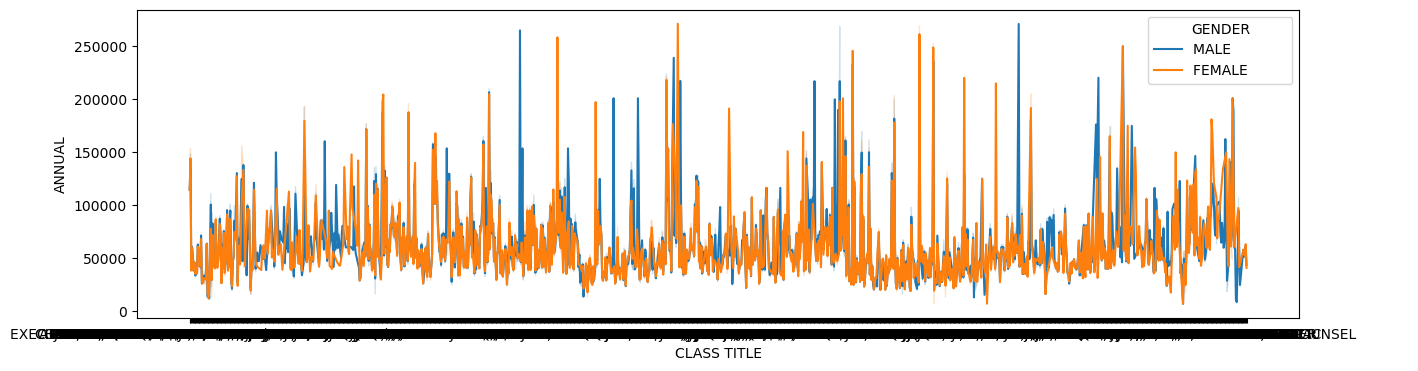

In [39]:
plt.figure(figsize=(15,4)) ##visualizing employee level salary difference using chart as Genderwise and there is negligible difference in the salary for same position 
sns.lineplot(x='CLASS TITLE',y='ANNUAL',data=employee,hue='GENDER')

In [49]:
df1.columns

Index(['AGENCY', 'AGENCY NAME', 'LAST NAME', 'FIRST NAME', 'MI', 'CLASS CODE',
       'CLASS TITLE', 'ETHNICITY', 'GENDER', 'STATUS', 'EMPLOY DATE',
       'HRLY RATE', 'HRS PER WK', 'MONTHLY', 'ANNUAL', 'STATE NUMBER',
       'year of service'],
      dtype='object')

<Axes: xlabel='year of service', ylabel='ANNUAL'>

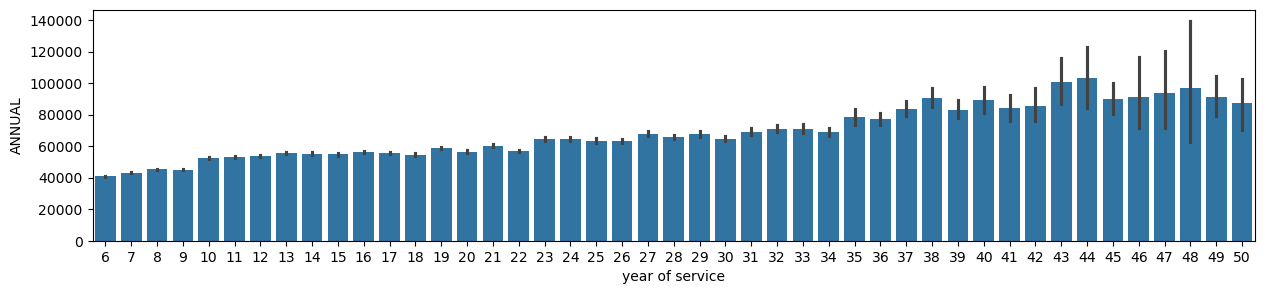

In [42]:
plt.figure(figsize=(15,3))  # Visualizing and notice that salary increases with the increase in experience
sns.barplot(x='year of service',y='ANNUAL',data=df1)

<Axes: xlabel='ETHNICITY', ylabel='ANNUAL'>

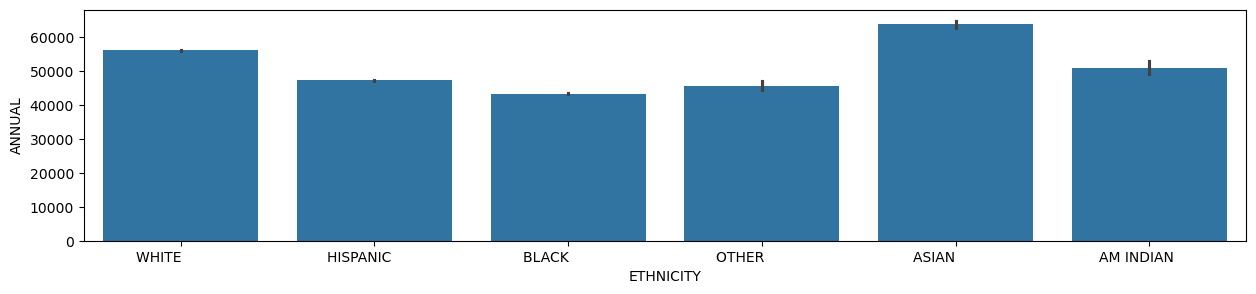

In [43]:
plt.figure(figsize=(15,3))  # Visualizing and noticed that ethnicity of a person affects the salary 
sns.barplot(x='ETHNICITY',y='ANNUAL',data=df1)

<Axes: xlabel='AGENCY', ylabel='ANNUAL'>

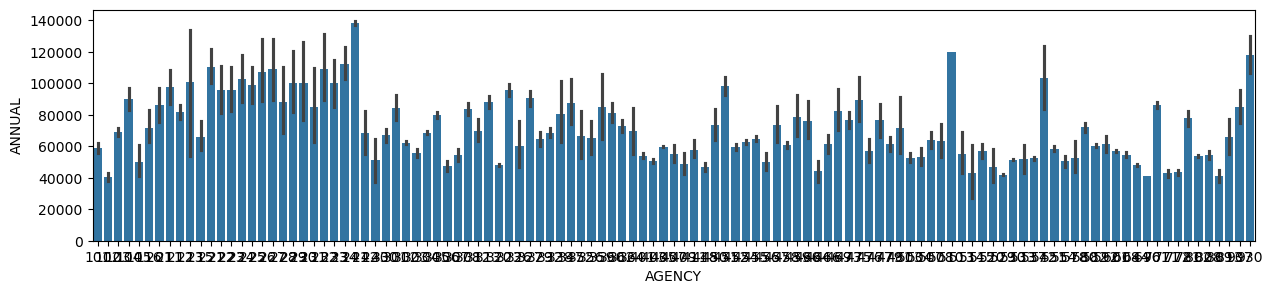

In [44]:
plt.figure(figsize=(15,3))  # Visualizing and noticed that various agency provides different salaries 
sns.barplot(x='AGENCY',y='ANNUAL',data=df1)

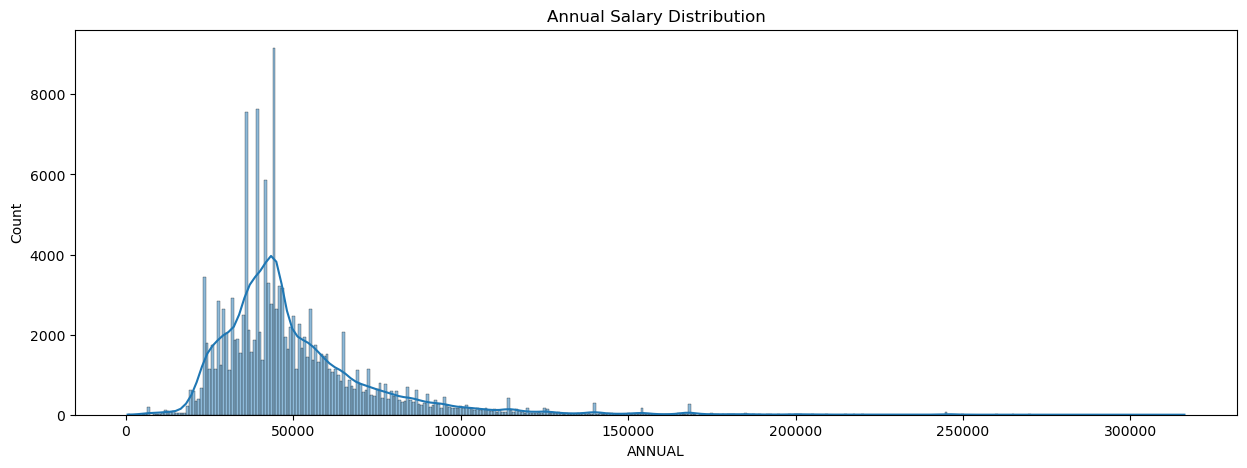

In [45]:
plt.figure(figsize=(15,5)) # Visualizing salary pattern and find that maximum person has salary between 20000 to 80000
sns.histplot(df1['ANNUAL'], kde=True)
plt.title("Annual Salary Distribution")
plt.show()


In [46]:
# Above Salary Distribution graph is Right-skewed distribution in which majority earn within a narrow mid-band while few areextremely high earners

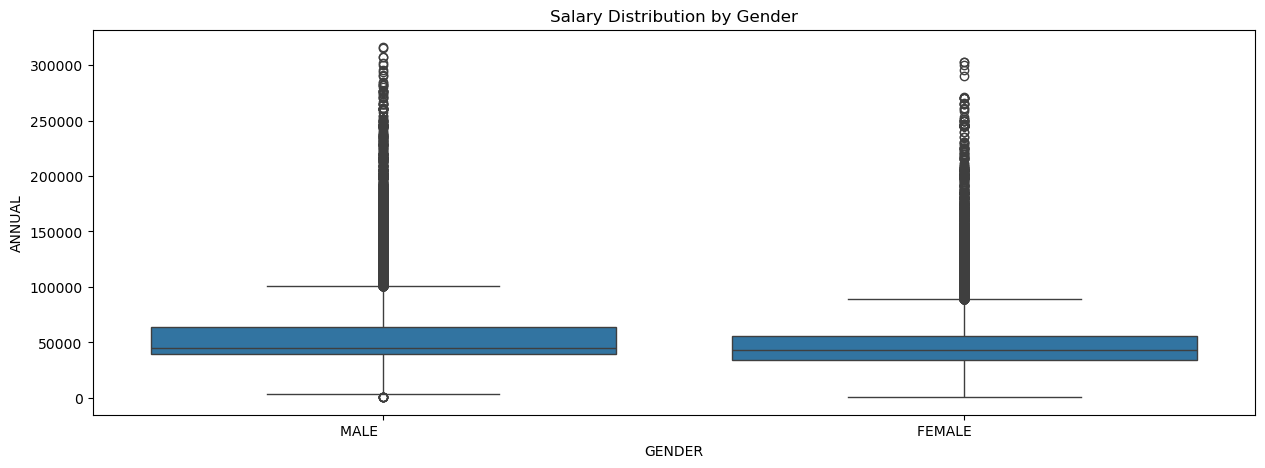

In [47]:
plt.figure(figsize=(15,5)) ##visualizing salary difference using chart as Genderwise and there is negligible difference in the salary for same position
sns.boxplot(x='GENDER', y='ANNUAL', data=df1)
plt.title("Salary Distribution by Gender")
plt.show()

## Data analysis completed

### Importing various model fo machine learning analysis

In [60]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import xgboost as xgb


In [61]:
model_df = df1[['AGENCY', 'CLASS TITLE', 'GENDER', 'ETHNICITY', 
               'year of service', 'HRLY RATE', 'HRS PER WK', 'ANNUAL']].dropna() #removing null values

for col in ['AGENCY', 'CLASS TITLE', 'GENDER', 'ETHNICITY']: # encoding data to convert into coded form
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])

x = model_df.drop('ANNUAL', axis=1) 
y = model_df['ANNUAL']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### # training and testing various model to determine which model is best suitable to  predict  for this dataset.

In [62]:
# GradientBoostingRegressor

gbr = GradientBoostingRegressor() 
gbr.fit(x_train, y_train)
gbr.score(x_test,y_test)
cross_val_score(GradientBoostingRegressor(),x,y,cv=5).mean()

y_pred = gbr.predict(x_test)
print("model Score:", gbr.score(x_test,y_test))
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("CV score", cross_val_score(GradientBoostingRegressor(),x,y,cv=5).mean())

model Score: 0.6220815991624904
R2 Score: 0.6220815991624904
MAE: 9000.014322384179
MSE: 242738002.53687623
CV score 0.45233976320057084


In [63]:
# LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)
lr.score(x_test,y_test)
cross_val_score(LinearRegression(),x,y,cv=5).mean()

y_pred = lr.predict(x_test)
print("model Score:", lr.score(x_test,y_test))
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("CV score", cross_val_score(LinearRegression(),x,y,cv=5).mean())

model Score: 0.20569647386446377
R2 Score: 0.20569647386446377
MAE: 14650.865974945578
MSE: 510183285.37285846
CV score 0.08275636814788043


In [64]:
# DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(x_train, y_train)
dt.score(x_test,y_test)
cross_val_score(DecisionTreeRegressor(),x,y,cv=5).mean()

y_pred = dt.predict(x_test)
print("model Score:", dt.score(x_test,y_test))
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("CV score", cross_val_score(DecisionTreeRegressor(),x,y,cv=5).mean())

model Score: 0.8815517716557077
R2 Score: 0.8815517716557077
MAE: 3614.665008036999
MSE: 76079614.7755915
CV score 0.5422877779349452


In [ ]:
# RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(x_train, y_train)
rf.score(x_test,y_test)
cross_val_score(RandomForestRegressor(),x,y,cv=5).mean()

y_pred = rf.predict(x_test)
print("model Score:", rf.score(x_test,y_test))
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("CV score", cross_val_score(RandomForestRegressor(),x,y,cv=5).mean())

In [ ]:
# Lasso

las = Lasso()
las.fit(x_train, y_train)
las.score(x_test,y_test)
cross_val_score(Lasso(),x,y,cv=5).mean()

y_pred = las.predict(x_test)
print("model Score:", las.score(x_test,y_test))
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("CV score", cross_val_score(Lasso(),x,y,cv=5).mean())

In [ ]:
# Ridge

rig = Ridge()
rig.fit(x_train, y_train)
rig.score(x_test,y_test)
cross_val_score(Ridge(),x,y,cv=5).mean()

y_pred = rig.predict(x_test)
print("model Score:", rig.score(x_test,y_test))
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("CV score", cross_val_score(Ridge(),x,y,cv=5).mean())

### Hyperparameter tuning

In [ ]:
pip install xgboost  # installing XGBoost

In [ ]:
# 1. XGBoost Tuning
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

xgb_grid = GridSearchCV(
    xgb.XGBRegressor(random_state=42),
    xgb_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)



In [ ]:
xgb_grid.fit(x_train, y_train)


In [ ]:
print(f"\nXGBoost Best Params: {xgb_grid.best_params_}")
print(f"XGBoost Best R2: {xgb_grid.best_score_:.4f}")

In [ ]:
# 2. Gradient Boosting Tuning
gb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)


In [ ]:
gb_grid.fit(x_train, y_train)


In [ ]:
print(f"\nGradient Boosting Best Params: {gb_grid.best_params_}")
print(f"Gradient Boosting Best R2: {gb_grid.best_score_:.4f}")

In [ ]:
model_df['CLASS TITLE'].value_counts

## Best score obtained by RandomForestClassifier 

### Below is the number assign to various values in each columns

In [ ]:
'''model_df['GENDER'] ##Female=0,Male=1 # 

model_df['ETHNICITY'] ## WHITE=5, HISPANIC=,3,BLACK=2,ASIAN=1,OTHER=4,AM INDIAN=0

model_df['Agency'] ## Agency numbers are [241 212 696 302 601 510 520 537 530 529 551 771 772 101 104 102 303 809 103 105 201 211 213 215 221 222 223 224 225 226 227 228 229 230 231 232
 233 234 242 243 300 301 304 306 307 313 320 323 326 329 332 338 352 360 401 403 405 407 448 452 454 455 457 458 459 460 464 469 473 479 481 503 508 513 515 533 542 554 608 644 701 
 781 802 813 907 930 116 305 308 312 327 347 356 359 362 364 409 411 450 451 456 466 475 476 477 504 507 514 578 580 582 592 808] 
 
 model_df['CLASS TITLE']  # from 0 to 709 '''

### Below is the prediction model to take input from the user.

In [ ]:
Agency=float(input("Enter Agency number"))
Class_Title=float(input("Enter Class Title"))
Gender=float(input("Gender"))
Ethinicity=float(input("Enter Ethinicity"))
year_of_service=float(input("Enter year of service"))
Hourly_rate=float(input("Enter Hourly rate "))
Hourly_per_week=float(input("Enter Hourly per week"))

Texas_salary_prediction=rf.predict([[Agency,Class_Title,Gender,Ethinicity,year_of_service,Hourly_rate,Hourly_per_week]])
print( )
print('Texas salary prdiction for the provided input data is',Texas_salary_prediction)

# REPORT

### The analysis reveals that salary distributions are right-skewed, with most employees clustered within a mid-income band and a small number of high-earning executive and specialist roles acting as natural outliers. These outliers are not errors but reflections of role-based compensation structures.

### Wage disparity analysis shows significant gaps between managerial and non-managerial roles. Gender and ethnicity-based differences exist but are more agency- and role-dependent than systemic across the entire state.

### Multiple predictive models were tested to estimate annual salaries. Among Linear Regressor, Decision Tree Regressor, Random Forest Regressor, and Gradient Boosting models, Random Forest Regressor delivered the best performance, achieving the highest R² score and lowest error makes it the most suitable model for prediction use.

### Overall, this project demonstrates how data-driven insights can support transparent payroll planning, identify inequities, and assist Texas state decision-makers in forecasting compensation responsibly.
